# Text Classification with OpenAI Embeddings and LLMs

This notebook moves beyond Bag of Words and a feed-forward neural network. We will use **vector embeddings** to represent articles semantically, then combine retrieval with an **OpenAI language model** to classify and explain predictions.

## Introduction for Junior Developers

In chapter 7, each article was represented by raw word counts. That works, but it ignores meaning. In this notebook we switch to **dense vector embeddings**, where each text becomes a list of numbers that captures semantic similarity.

### Key Concepts
1. **Vector embeddings** turn text into dense numeric representations.
2. **Cosine similarity** lets us compare how close two text vectors are.
3. **Class prototypes** summarize each class with an average embedding.
4. **Retrieval** finds the most similar examples for a new input.
5. **LLMs** can use retrieved context to make and explain predictions.

### The Pipeline

<img src="assets/diagrams/v4-intro-pipeline.svg" alt="Embeddings and LLM pipeline" width="420">

## Environment and API Setup

This notebook uses the `openai` Python package and reads `OPENAI_API_KEY` from a local `.env` file or your shell environment.

Small setup checklist:

1. Install dependencies from `requirements.txt`.
2. Put your key in `.env`.
3. Restart the kernel if you installed packages during this session.

If needed, install dependencies first:

```python
%pip install -q -r requirements.txt
```

In [18]:
import json
import os
import random
from textwrap import shorten

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from tqdm import tqdm

load_dotenv()
tqdm.pandas()

seed = 1234
random.seed(seed)
np.random.seed(seed)

EMBEDDING_MODEL = 'text-embedding-3-small'
CHAT_MODEL = 'gpt-4.1-mini'

api_key = os.getenv('OPENAI_API_KEY')
client = OpenAI(api_key=api_key) if api_key else None

print(f'random seed: {seed}')
print(f'embedding model: {EMBEDDING_MODEL}')
print(f'chat model: {CHAT_MODEL}')
print('OPENAI_API_KEY detected.' if api_key else 'Set OPENAI_API_KEY in .env or your shell before running embedding or LLM cells.')

random seed: 1234
embedding model: text-embedding-3-small
chat model: gpt-4.1-mini
OPENAI_API_KEY detected.


## Load the AG News Dataset

We will keep the same dataset as chapter 7 so the comparison stays fair. Each example contains a class label, a title, and a short description.

In [19]:
labels = open('data/ag_news_csv/classes.txt').read().splitlines()

train_df = pd.read_csv('data/ag_news_csv/train.csv', header=None)
train_df.columns = ['class index', 'title', 'description']
train_df.insert(1, 'class', train_df['class index'].map(lambda i: labels[i - 1]))
train_df['text'] = (train_df['title'].fillna('') + ' ' + train_df['description'].fillna('')).str.lower()
train_df['text'] = train_df['text'].str.replace('\\', ' ', regex=False).str.replace(r'\s+', ' ', regex=True).str.strip()

test_df = pd.read_csv('data/ag_news_csv/test.csv', header=None)
test_df.columns = ['class index', 'title', 'description']
test_df.insert(1, 'class', test_df['class index'].map(lambda i: labels[i - 1]))
test_df['text'] = (test_df['title'].fillna('') + ' ' + test_df['description'].fillna('')).str.lower()
test_df['text'] = test_df['text'].str.replace('\\', ' ', regex=False).str.replace(r'\s+', ' ', regex=True).str.strip()

print(f'train rows: {len(train_df):,}')
print(f'test rows: {len(test_df):,}')
train_df.head()

train rows: 120,000
test rows: 7,600


,class index,class,title,description,text
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",wall st. bears claw back into the black (reute...
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,carlyle looks toward commercial aerospace (reu...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,oil and economy cloud stocks' outlook (reuters...
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,iraq halts oil exports from main southern pipe...
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","oil prices soar to all-time record, posing new..."


## Use a Smaller Working Split

OpenAI API calls cost money and take time, so we will use a stratified subset for experimentation. You can increase these sizes later if needed.

In [20]:
train_small, _ = train_test_split(
    train_df,
    train_size=2000,
    random_state=seed,
    stratify=train_df['class index'],
)

dev_small, _ = train_test_split(
    test_df,
    train_size=400,
    random_state=seed,
    stratify=test_df['class index'],
)

llm_eval_df, _ = train_test_split(
    dev_small,
    train_size=24,
    random_state=seed,
    stratify=dev_small['class index'],
)

train_small = train_small.reset_index(drop=True)
dev_small = dev_small.reset_index(drop=True)
llm_eval_df = llm_eval_df.reset_index(drop=True)

print(train_small['class'].value_counts().sort_index())
print()
print(f'embedding training rows: {len(train_small):,}')
print(f'embedding evaluation rows: {len(dev_small):,}')
print(f'llm evaluation rows: {len(llm_eval_df):,}')

class
Business    500
Sci/Tech    500
Sports      500
World       500
Name: count, dtype: int64

embedding training rows: 2,000
embedding evaluation rows: 400
llm evaluation rows: 24


## Create Embeddings

The embedding model turns each article into a dense vector. We will batch requests to stay efficient.

In [21]:
def require_openai_client():
    if client is None:
        raise RuntimeError('OPENAI_API_KEY is not set. Export it before running OpenAI cells.')


def embed_texts(texts, model=EMBEDDING_MODEL, batch_size=100):
    require_openai_client()
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc='embedding batches'):
        batch = texts[start:start + batch_size]
        response = client.embeddings.create(model=model, input=batch)
        vectors.extend(item.embedding for item in response.data)
    return np.array(vectors, dtype=np.float32)

In [22]:
train_embeddings = embed_texts(train_small['text'].tolist())
dev_embeddings = embed_texts(dev_small['text'].tolist())

print(train_embeddings.shape)
print(dev_embeddings.shape)

embedding batches: 100%|██████████| 4/4 [00:02<00:00,  1.59it/s]

(2000, 1536)
(400, 1536)


## Prototype Classifier with Cosine Similarity

A simple baseline is to average all embeddings for each class. This gives us one **prototype vector** per class. Then we compare each new article to the prototypes and choose the closest one.

In [23]:
class_names = sorted(train_small['class'].unique())
label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

prototype_vectors = []
for label in class_names:
    mask = train_small['class'] == label
    prototype = train_embeddings[mask.to_numpy()].mean(axis=0)
    prototype_vectors.append(prototype)

prototype_vectors = np.vstack(prototype_vectors)
prototype_vectors.shape

(4, 1536)

In [24]:
prototype_scores = cosine_similarity(dev_embeddings, prototype_vectors)
prototype_pred_idx = prototype_scores.argmax(axis=1)
prototype_pred = [index_to_label[idx] for idx in prototype_pred_idx]
prototype_true = dev_small['class'].tolist()

print(f'prototype accuracy: {accuracy_score(prototype_true, prototype_pred):.3f}')
print(classification_report(prototype_true, prototype_pred, target_names=class_names))

prototype accuracy: 0.897
              precision    recall  f1-score   support

    Business       0.86      0.86      0.86       100
    Sci/Tech       0.85      0.86      0.86       100
      Sports       0.98      0.97      0.97       100
       World       0.90      0.90      0.90       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



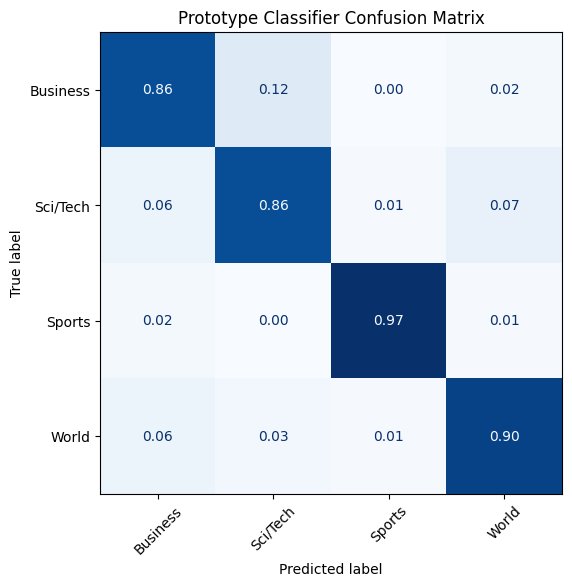

In [25]:
cm = confusion_matrix(prototype_true, prototype_pred, labels=class_names, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='.2f', colorbar=False, ax=ax, xticks_rotation=45)
plt.title('Prototype Classifier Confusion Matrix')
plt.show()

## Retrieve Similar Training Examples

Retrieval is useful because it gives the model concrete examples to compare against. We will search the embedding space for the nearest neighbors of a query article.

In [26]:
def retrieve_examples(query_text, top_k=5):
    query_embedding = embed_texts([query_text])
    similarities = cosine_similarity(query_embedding, train_embeddings)[0]
    top_idx = similarities.argsort()[::-1][:top_k]
    result = train_small.loc[top_idx, ['class', 'title', 'description', 'text']].copy()
    result.insert(0, 'similarity', similarities[top_idx])
    return result.reset_index(drop=True)

In [27]:
query_row = dev_small.sample(1, random_state=seed).iloc[0]
print('query label:', query_row['class'])
print(shorten(query_row['text'], width=180, placeholder='...'))
retrieve_examples(query_row['text'], top_k=5)[['similarity', 'class', 'title']]

query label: Business
product previews palmoneupgrades treo with faster chip, better display with more than 600,000 units shipped, the treo 600 is one of the big smartphone success stories. last...


embedding batches: 100%|██████████| 1/1 [00:00<00:00,  6.76it/s]


,similarity,class,title
0,0.498336,Sci/Tech,AMD Shows Off 2005 Mobile Line
1,0.492928,Sci/Tech,Dell launches Axim X50 wireless media PDAs
2,0.481829,Sci/Tech,Wireless messaging and data access software ad...
3,0.475576,Sci/Tech,Linux-based Palm OS on chart
4,0.457545,Sci/Tech,Memory boost for Nokia phones by #39;05


## Add an LLM on Top of Retrieval

Now we give a chat model the target article plus a few retrieved examples. This is a lightweight form of retrieval-augmented generation.

To keep cost under control, we only evaluate a very small subset.

In [28]:
class ClassificationResult(BaseModel):
    predicted_label: str
    explanation: str


def classify_with_llm(text, top_k=4):
    require_openai_client()
    retrieved = retrieve_examples(text, top_k=top_k)
    
    examples = retrieved[['class', 'title', 'description', 'similarity']].copy()
    examples['similarity'] = examples['similarity'].round(4)
    
    prompt = {
        'task': 'Classify one AG News article into exactly one class.',
        'allowed_classes': class_names,
        'article': text,
        'retrieved_examples': examples.to_dict(orient='records'),
        'instructions': [
            'Use the retrieved examples as evidence, but classify the target article on its own meaning.',
            'Return strict JSON with keys predicted_label and explanation.',
            'predicted_label must be one of the allowed classes exactly.'
        ]
    }
    
    response = client.responses.parse(
        model=CHAT_MODEL,
        input=[
            {
                'role': 'system',
                'content': 'You are a careful text classification assistant. Output only JSON.'
            },
            {
                'role': 'user',
                'content': json.dumps(prompt, ensure_ascii=True)
            }
        ],
        text_format=ClassificationResult,
    )
    
    output = response.output_parsed
    if output is None:
        raise ValueError(f'LLM did not return parseable JSON. Raw output: {response.output_text!r}')
    
    predicted_label = output.predicted_label
    if predicted_label not in class_names:
        raise ValueError(f'Unexpected label returned: {predicted_label}')
    return predicted_label, output.explanation, retrieved

In [29]:
example_prediction, example_explanation, example_neighbors = classify_with_llm(query_row['text'])
print('gold label:', query_row['class'])
print('predicted label:', example_prediction)
print()
print(example_explanation)
example_neighbors[['similarity', 'class', 'title']]

embedding batches: 100%|██████████| 1/1 [00:00<00:00,  6.98it/s]


gold label: Business
predicted label: Sci/Tech

The article discusses the features and improvements of the PalmOne Treo 650 smartphone, including technical specifications like a faster chip, improved display, multimedia capabilities, and pricing. This focus on technology and product details fits squarely within the Sci/Tech category. The retrieved examples are also related to technology product launches, supporting this classification.


,similarity,class,title
0,0.498336,Sci/Tech,AMD Shows Off 2005 Mobile Line
1,0.492928,Sci/Tech,Dell launches Axim X50 wireless media PDAs
2,0.481829,Sci/Tech,Wireless messaging and data access software ad...
3,0.475576,Sci/Tech,Linux-based Palm OS on chart


In [30]:
records = []
for row in tqdm(list(llm_eval_df.itertuples(index=False)), desc='llm evaluation'):
    predicted_label, explanation, _ = classify_with_llm(row.text, top_k=4)
    records.append({
        'gold': row[1],
        'predicted': predicted_label,
        'title': row[2],
        'explanation': explanation,
    })

llm_results = pd.DataFrame(records)
print(f'llm subset accuracy: {accuracy_score(llm_results['gold'], llm_results['predicted']):.3f}')
print(classification_report(llm_results['gold'], llm_results['predicted'], target_names=class_names))
llm_results.head()

llm evaluation: 100%|██████████| 24/24 [00:52<00:00,  2.17s/it]

llm subset accuracy: 0.875
              precision    recall  f1-score   support

    Business       0.75      1.00      0.86         6
    Sci/Tech       1.00      0.83      0.91         6
      Sports       0.86      1.00      0.92         6
       World       1.00      0.67      0.80         6

    accuracy                           0.88        24
   macro avg       0.90      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24



,gold,predicted,title,explanation
0,Business,Business,Martha Stewart reports to jail to begin sentence,The article discusses Martha Stewart reporting...
1,World,World,Changes to Nigeria union bill,The article discusses legislative changes in N...
2,Sports,Sports,"US women avoid disaster, advance",The article discusses the performance of the U...
3,World,Business,SKorea's Samsung to invest 24 billion dollars ...,The article discusses South Korea's Samsung El...
4,World,Sports,England humble Sprinboks,The article describes England defeating the Sp...


## What Changed Compared with Chapter 7?

The FFNN notebook learned directly from sparse word-count vectors. In this notebook, we rely on a pretrained embedding model to supply semantic representations first.

That gives us three practical benefits:
1. We can compare articles by meaning, not just exact token overlap.
2. We can build a reasonable classifier without training a neural network from scratch.
3. We can retrieve similar examples and hand them to an LLM for more interpretable predictions.

Good next experiments:
- increase the embedding subset size
- compare `text-embedding-3-small` against `text-embedding-3-large`
- store vectors in a proper vector database
- ask the chat model for calibrated confidence estimates
- turn this notebook into a retrieval-augmented API service